# 2. Ontologies & EMMO

Notebook 1 showed that a value needs metadata to be reusable — a number
needs a name, a unit, a sample ID. This notebook asks the next question:
how do you make sure *your* name for something ("yield strength") means
exactly the same thing as *someone else's* name for it, to both a human
reader and a piece of software? That is the problem **ontologies** solve,
and **EMMO** (the European Materials Modelling Ontology) is the specific
ontology this course uses as a worked example.

**Topics**
1. The problem: same word, different meaning (and vice versa)
2. What an ontology actually is (classes, individuals, "is-a" relations)
3. Controlled vocabulary vs. taxonomy vs. ontology
4. EMMO: what it is, and why materials science needs one
5. Hands-on: building a small ontology in Python with `owlready2`
6. Hands-on: exploring the real EMMO with `rdflib` and SPARQL
7. Seeing the ontology as a graph (visualising it with `networkx`)
8. Reasoning: deriving facts that were never explicitly stated
9. Closing the loop: fixing the synonymy problem from Section 2.1
10. Catching a dimensionally wrong unit a plain CSV column would miss

## 2.1 The Problem: Words Are Not Reliable Identifiers

Two failure modes show up constantly when combining datasets from different
labs, instruments, or papers:

- **Synonymy** — the same concept, different words. "Yield strength",
  "0.2% proof stress", and "$\sigma_y$" all refer to the same physical
  quantity; a script that filters by the exact string `"yield_strength"`
  will silently miss the other two.
- **Homonymy** — the same word, different concepts. "Annealing" means
  something different in metallurgy (a heat treatment to relieve stress)
  than in molecular biology (letting DNA strands re-anneal), and even within
  materials science, "conductivity" alone is ambiguous between electrical
  and thermal conductivity without a unit or qualifier attached.

A spreadsheet column header is just a string — it cannot tell a computer
which of these it means. An **ontology** fixes this by giving every concept
a single, unambiguous, machine-readable identity (in practice: a URI) and
by formally stating how concepts relate to one another, so software (and
careful humans) can tell "these two columns mean the same thing" from
"these two columns merely look similar.

## 2.2 What Is an Ontology?

Strip away the jargon and an ontology is a formal, computer-readable version
of something you already build informally whenever you organise ideas: a
hierarchy of **classes** ("kinds of thing"), **individuals** ("specific
instances of a kind"), and **relations** between them, plus a rule that a
more specific class **inherits** everything true of the more general class
above it — usually called an **"is-a" hierarchy**.

A familiar, non-materials example: biological taxonomy.

```
Animal
 └── Mammal
      └── Carnivore
           └── Felidae (cats)
                └── Panthera leo (lion)   ← an individual: "Simba"
```

"Every `Felidae` is a `Carnivore`" is a class-level statement (an **axiom**);
"Simba is a `Panthera leo`" relates a specific **individual** to a class.
Because the hierarchy is explicit, a query for "all carnivores" automatically
includes lions without anyone having to list every species by hand — the
same benefit you want when querying "all thermodynamic quantities" in a
materials database and getting temperature, entropy, *and* heat capacity
back, without hand-maintaining that list yourself.

Ontologies add one more ingredient beyond a plain hierarchy: **relations**
other than "is-a" — e.g. "a `SynthesisProcess` **has** a `Temperature`" —
which is what lets an ontology describe not just categories, but how real
things are connected.

## 2.3 Controlled Vocabulary vs. Taxonomy vs. Ontology

These three terms are often used loosely; it helps to know where each one
stops.

| Level | What it provides | Example | Limitation |
|---|---|---|---|
| **Controlled vocabulary** | A fixed, agreed-upon list of allowed terms | `{"as-cast", "annealed", "quenched"}` for a "condition" field | No structure between terms — flat list only |
| **Taxonomy** | A controlled vocabulary *plus* an is-a hierarchy | Linnaean biological classification | Only one relation type (is-a); no formal logic |
| **Ontology** | A taxonomy *plus* additional relations, properties, and formal logical axioms that software can reason over | EMMO | Requires more upfront modelling effort |

Materials data often starts life governed only by a controlled vocabulary
(a dropdown menu in a lab's electronic notebook). An ontology is what you
reach for once you need software to *combine* data across many such
vocabularies automatically — which is precisely the situation a shared
European materials-data infrastructure is in.

## 2.4 Introducing EMMO

**EMMO** — the **E**uropean **M**aterials & **M**odelling **O**ntology
(originally: Elementary Multiperspective Material Ontology) — is a
*foundational* (or "top-level") ontology purpose-built for physical
science and engineering. It is developed and maintained by the **European
Materials Modelling Council (EMMC)** as an open, versioned OWL ontology,
published at the persistent identifier `https://w3id.org/emmo` and hosted
on GitHub at `github.com/emmo-repo/EMMO` under a CC-BY-4.0 licence.

What makes EMMO different from "just another controlled vocabulary" is that
it is grounded in formal philosophy and physics rather than convenience:
every concept ultimately derives from a single root class (`Item`), and
reality is organised through several formal **"Perspectives"** — for
example a *causal* perspective (how things influence each other) and a
*semiotic* perspective (how signs, symbols, and data represent things) —
rather than one flat "is-a" tree. You do not need to master this philosophy
to use EMMO productively, but it is why EMMO can precisely represent a
subtlety that trips up simpler vocabularies: **a measured value is not the
same thing as the physical property it describes** — "188 HV" is a *sign*
that represents a real hardness, and EMMO models that distinction
explicitly (you will see this concretely in Section 2.6).

EMMO is not meant to be used alone — domain-specific ontologies are built
*on top of* it so that different domains stay interoperable through a
shared foundation. **BattINFO** (the Battery Interface Ontology), used for
FAIR battery data across European projects, is a well-known example built
this way. **NOMAD** (Notebook 4) increasingly annotates its own schemas with
EMMO concepts for exactly this reason: so that a "temperature" recorded in
NOMAD means the same formal thing as a "temperature" recorded anywhere else
that also uses EMMO.

## 2.5 Hands-on: Building a Small Ontology with `owlready2`

The real EMMO's top level is organised around formal Perspectives rather
than a simple two-branch split, which is more machinery than we need for a
first hands-on exercise. Instead, we will build a small, EMMO-*inspired*
toy ontology from scratch — materials as physical objects, syntheses as
processes, and properties as quantities — using the same basic building
blocks (classes, subclass axioms, relations, individuals) that EMMO itself
is built from. `owlready2` lets you define an ontology using ordinary Python
class syntax.

In [1]:
from owlready2 import Thing, ObjectProperty, get_ontology, default_world

onto = get_ontology('http://example.org/mini_materials_onto.owl')

with onto:
    # ── Top-level split (simplified — see note above about the real EMMO) ────
    class Item(Thing):
        """Root class: everything nameable in this toy ontology is an Item."""

    class PhysicalEntity(Item):
        """Something that exists independently in space and time."""

    class Quantity(Item):
        """A sign that encodes a measured magnitude: a number plus a unit."""

    # ── Physical entities split into persisting objects and processes ────────
    class MaterialObject(PhysicalEntity):
        """A physical object considered as a whole persisting through time."""

    class Process(PhysicalEntity):
        """A physical entity considered as it unfolds through time."""

    class CathodeMaterial(MaterialObject):
        pass

    class SynthesisProcess(Process):
        pass

    class ThermodynamicTemperature(Quantity):
        pass

    class ElectricCharge(Quantity):
        pass

    # ── Relations: how entities connect to quantities ─────────────────────────
    class hasQuantitativeProperty(PhysicalEntity >> Quantity):
        """Relates a physical object/process to a quantity describing it."""

    class hasSynthesisTemperature(SynthesisProcess >> ThermodynamicTemperature):
        is_a = [hasQuantitativeProperty]

    class hasMeasuredCapacity(CathodeMaterial >> ElectricCharge):
        is_a = [hasQuantitativeProperty]

print('Classes defined:', [c.name for c in onto.classes()])

Classes defined: ['Item', 'PhysicalEntity', 'Quantity', 'MaterialObject', 'Process', 'CathodeMaterial', 'SynthesisProcess', 'ThermodynamicTemperature', 'ElectricCharge']


Now that the classes exist, we can ask the same kind of questions you would
ask of the real EMMO: what is a subclass of what, and what does a given
class ultimately descend from?

In [2]:
print('Subclasses of PhysicalEntity:', [c.name for c in PhysicalEntity.subclasses()])
print('Subclasses of Quantity:      ', [c.name for c in Quantity.subclasses()])
print()
print('CathodeMaterial.is_a (direct parents):', [c.name for c in CathodeMaterial.is_a])
print('CathodeMaterial ancestors (full chain):',
      [c.name for c in CathodeMaterial.ancestors() if hasattr(c, 'name')])

Subclasses of PhysicalEntity: ['MaterialObject', 'Process']
Subclasses of Quantity:       ['ThermodynamicTemperature', 'ElectricCharge']

CathodeMaterial.is_a (direct parents): ['MaterialObject']
CathodeMaterial ancestors (full chain): ['Thing', 'CathodeMaterial', 'MaterialObject', 'PhysicalEntity', 'Item']


### Individuals: describing one real sample

Classes describe *kinds* of thing; **individuals** are the specific
instances — this is where your actual lab data enters the ontology. Compare
this to `cathode_record` in Notebook 1: there, `'quantity_kind_iri'` was a
plain string comment pointing at a concept; here, the link is a real,
machine-checkable relation.

In [3]:
sample = CathodeMaterial('LiFePO4_batch_07')
synthesis = SynthesisProcess('synthesis_of_batch_07')
T_synth = ThermodynamicTemperature('T_synthesis_batch_07')
capacity = ElectricCharge('capacity_batch_07')

synthesis.hasSynthesisTemperature.append(T_synth)
sample.hasMeasuredCapacity.append(capacity)

print(f'{sample.name} is a {[c.name for c in sample.is_a]}')
print(f'{synthesis.name} hasSynthesisTemperature -> '
      f'{[t.name for t in synthesis.hasSynthesisTemperature]}')
print(f'{sample.name} hasMeasuredCapacity -> '
      f'{[c.name for c in sample.hasMeasuredCapacity]}')

LiFePO4_batch_07 is a ['CathodeMaterial']
synthesis_of_batch_07 hasSynthesisTemperature -> ['T_synthesis_batch_07']
LiFePO4_batch_07 hasMeasuredCapacity -> ['capacity_batch_07']


Finally, save the ontology to disk. This is a real, valid OWL file —
exactly the kind of artefact EMMO itself is distributed as (just far
larger), and one that any OWL-aware tool (Protégé, `owlready2`, `rdflib`,
NOMAD's schema tooling) can open.

In [4]:
onto.save(file='mini_materials_onto.owl', format='rdfxml')

with open('mini_materials_onto.owl', encoding='utf-8') as f:
    text = f.read()
print(f'Saved {len(text)} characters of OWL/XML.')
print(text[:600] + '\n...')

Saved 2680 characters of OWL/XML.
<?xml version="1.0"?>
<rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
         xmlns:xsd="http://www.w3.org/2001/XMLSchema#"
         xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#"
         xmlns:owl="http://www.w3.org/2002/07/owl#"
         xml:base="http://example.org/mini_materials_onto.owl"
         xmlns="http://example.org/mini_materials_onto.owl#">

<owl:Ontology rdf:about="http://example.org/mini_materials_onto.owl"/>

<owl:ObjectProperty rdf:about="#hasQuantitativeProperty">
  <rdfs:domain rdf:resource="#PhysicalEntity"/>
  <rdfs:range rdf:resource="#Quantity"/>
<
...


## 2.6 Hands-on: Exploring the Real EMMO

Now let's look at the real thing. EMMO is published as Turtle (`.ttl`), and
`rdflib` can load it directly from its canonical URL — no download step
needed, no account or API key required (this is a public ontology file, not
a database query, so it fits the "conceptual, read-only" spirit of this
part). Loading it fetches roughly 60,000 triples and can take a few seconds;
if you have no internet connection right now, read the expected output in
the surrounding text and come back to run this cell later.

In [5]:
import rdflib

emmo = rdflib.Graph()
emmo_loaded = False
try:
    emmo.parse('https://w3id.org/emmo', format='turtle')
    emmo_loaded = True
    print(f'Loaded EMMO: {len(emmo)} triples')
except Exception as e:
    print(f'Could not reach EMMO right now ({type(e).__name__}: {e}).')
    print('Skip ahead and re-run this cell later when you have a connection.')

Loaded EMMO: 61530 triples


### Reading the ontology's own metadata

An ontology describes itself, too — this is the same idea as the FAIR
metadata from Notebook 1, applied to EMMO itself. Every well-published
ontology should be able to answer "what version am I, who publishes me,
under what licence?" directly from its own file.

In [6]:
if emmo_loaded:
    q_meta = """
    PREFIX dcterms: <http://purl.org/dc/terms/>
    PREFIX owl: <http://www.w3.org/2002/07/owl#>
    SELECT ?title ?version ?license ?homepage WHERE {
        ?ont a owl:Ontology .
        OPTIONAL { ?ont dcterms:title ?title }
        OPTIONAL { ?ont owl:versionInfo ?version }
        OPTIONAL { ?ont dcterms:license ?license }
        OPTIONAL { ?ont <http://xmlns.com/foaf/0.1/homepage> ?homepage }
    }
    """
    for row in emmo.query(q_meta):
        print('Title:   ', row.title)
        print('Version: ', row.version)
        print('Licence: ', row.license)
        print('Homepage:', row.homepage)

Title:    EMMO Maximal (EMAX)
Version:  1.0.3
Licence:  https://creativecommons.org/licenses/by/4.0/legalcode
Homepage: https://github.com/emmo-repo/EMMO


### Walking a real ancestor chain: `Crystal`

This is the payoff of Section 2.2's "is-a" idea, at full scale. We ask EMMO:
*"what is a `Crystal`, ultimately?"* — and follow every `rdfs:subClassOf`
link upward with a single SPARQL query using the `+` (one-or-more) path
operator.

In [7]:
def find_class_by_label(graph, label):
    q = f"""
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    SELECT ?s WHERE {{ ?s rdfs:label "{label}"@en }}
    """
    rows = list(graph.query(q))
    if not rows:
        q = f"""
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
        SELECT ?s WHERE {{ ?s rdfs:label ?l . FILTER(STR(?l) = "{label}") }}
        """
        rows = list(graph.query(q))
    return rows[0][0] if rows else None


def ancestor_chain(graph, class_iri):
    q = f"""
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    SELECT ?anc ?label WHERE {{
        <{class_iri}> rdfs:subClassOf+ ?anc .
        FILTER(isIRI(?anc))
        OPTIONAL {{ ?anc rdfs:label ?label }}
    }}
    """
    return [str(row.label) for row in graph.query(q) if row.label]


if emmo_loaded:
    crystal_iri = find_class_by_label(emmo, 'Crystal')
    print('Crystal IRI:', crystal_iri)
    print('Named ancestors of Crystal:')
    for name in ancestor_chain(emmo, crystal_iri):
        print(' ', name)

Crystal IRI: https://w3id.org/emmo#EMMO_0bb3b434_73aa_428f_b4e8_2a2468648e19
Named ancestors of Crystal:
  CrystallineMaterial
  MaterialByStructure
  MaterialByClassicalMaterialsScience
  Material
  OrdinaryMatter
  MatterByType
  Matter
  PhysicalObject
  InteractingSystem
  GenericPhysicalSystem
  CausalSystem
  CausalCluster
  Fusion
  EMMO
  CausalStructure
  Item
  Substance
  MatterByStructure
  CompositePhysicalObject
  PhysicalObjectByBond


Notice that `Crystal` climbs through `CrystallineMaterial`, `Material`,
`OrdinaryMatter`, `PhysicalObject`, all the way up to the root `Item` — a
much deeper and more careful hierarchy than a spreadsheet dropdown could
ever encode, and precisely why a query for "all `PhysicalObject`" would
correctly retrieve a `Crystal` sample without you ever writing that
connection by hand.

### The payoff: a *quantity* is modelled as a *sign*

Now repeat the same query for `SpecificHeatCapacity` — a physical
**quantity**, not a physical **object** like `Crystal`.

In [8]:
if emmo_loaded:
    shc_iri = find_class_by_label(emmo, 'SpecificHeatCapacity')
    print('SpecificHeatCapacity IRI:', shc_iri)
    print('Named ancestors of SpecificHeatCapacity:')
    for name in ancestor_chain(emmo, shc_iri):
        print(' ', name)

SpecificHeatCapacity IRI: https://w3id.org/emmo#EMMO_b4f4ed28_d24c_4a00_9583_62ab839abeca
Named ancestors of SpecificHeatCapacity:


  ISQDerivedQuantity
  DerivedQuantity
  PhysicalQuantiyByDefinition
  PhysicalQuantity
  QuantityByPhysicalNature
  Quantity
  Property
  CodedByStructure
  Coded
  Conventional
  SignByReferent
  Sign
  SemioticEntity
  Semiotics
  Perspective
  CausalStructure
  Fusion
  EMMO
  Item
  InternationalSystemOfQuantity
  StandardizedPhysicalQuantity
  Intensive
  CategorizedPhysicalQuantity
  ThermodynamicalQuantity
  ISO80000Categorised


Look closely at that list: `SpecificHeatCapacity` passes through `Sign`,
`SemioticEntity`, and `Semiotics` on its way up — the same "semiotic
perspective" mentioned in Section 2.4. EMMO is formally stating that a
*quantity* (a number with a unit) is a **sign that represents** a real
physical property, not the property itself. This is exactly the distinction
Notebook 1 asked you to keep straight informally ("188 HV" is not the
hardness itself, it is a *record* of the hardness) — EMMO simply makes it a
first-class, queryable fact instead of a habit you have to remember.

## 2.7 Seeing the Ontology as a Graph

Everything built in Section 2.5 has been graph structure the whole time:
classes linked by `is_a` edges, individuals linked to their classes, and
individuals linked to *each other* by object properties
(`hasSynthesisTemperature`, `hasMeasuredCapacity`). Drawing it as an actual
graph makes that concrete — this is what people mean by **knowledge
graph**: not a metaphor, a literal network of typed nodes and labelled
edges that both a person and a SPARQL query can traverse.

Graph: 13 nodes, 14 edges


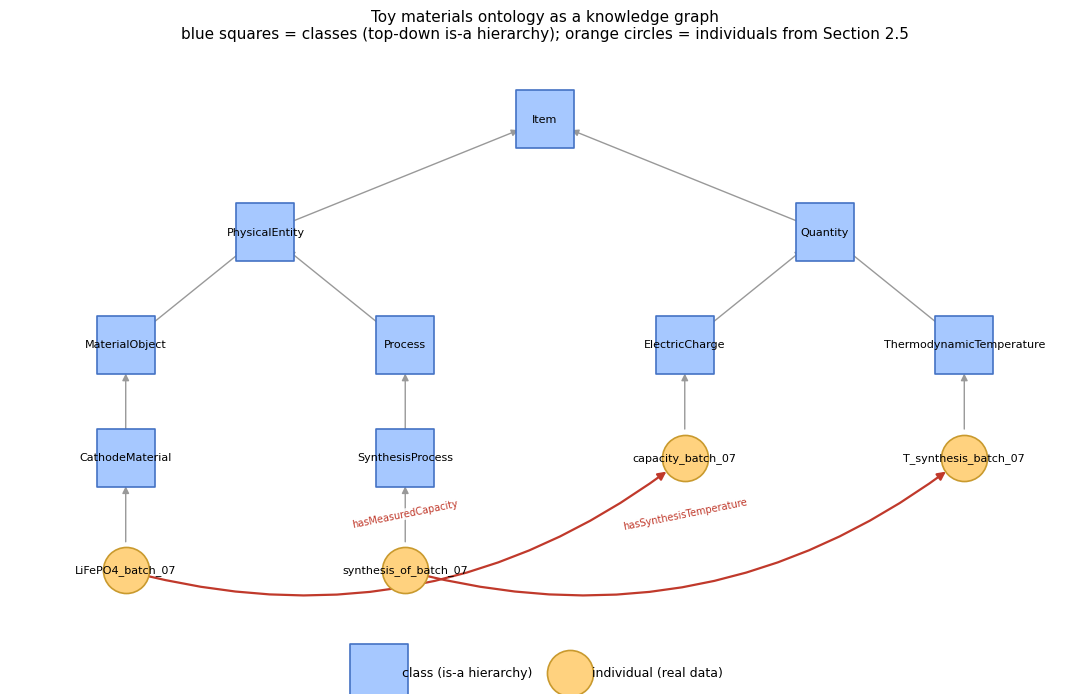

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
class_nodes, ind_nodes = [], []

for cls in onto.classes():
    G.add_node(cls.name, kind='class')
    class_nodes.append(cls.name)
    for parent in cls.is_a:
        if hasattr(parent, 'name') and parent.name != 'Thing':
            G.add_edge(cls.name, parent.name, kind='is-a')

for ind in onto.individuals():
    G.add_node(ind.name, kind='individual')
    ind_nodes.append(ind.name)
    for cls in ind.is_a:
        if hasattr(cls, 'name'):
            G.add_edge(ind.name, cls.name, kind='is-a')
    for prop in ind.get_properties():
        for value in prop[ind]:
            if hasattr(value, 'name'):
                G.add_edge(ind.name, value.name, kind=prop.python_name)

print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

# This toy ontology has strict single inheritance, so the is-a + instance-of
# edges form a real tree rooted at Item. Lay it out like a dendrogram instead
# of a generic force-directed layout: each node's depth is its distance from
# Item, and each parent is centred above the midpoint of its own children --
# this gives a crossing-free hierarchy instead of a tangle of crossing edges.
is_a_edges = [(u, v) for u, v, d in G.edges(data=True) if d['kind'] == 'is-a']
is_a_graph = nx.DiGraph(is_a_edges)

depth = {'Item': 0}
for cls in class_nodes:
    if cls != 'Item':
        depth[cls] = nx.shortest_path_length(is_a_graph, cls, 'Item')
for ind in ind_nodes:
    parent_classes = [v for u, v, d in G.edges(data=True) if u == ind and d['kind'] == 'is-a']
    depth[ind] = max(depth[p] for p in parent_classes) + 1

children = {}
for u, v in is_a_edges:
    children.setdefault(v, []).append(u)

x_counter = [0]
pos_x = {}


def assign_x(node):
    kids = sorted(children.get(node, []))
    if not kids:
        pos_x[node] = x_counter[0]
        x_counter[0] += 1
        return
    for k in kids:
        assign_x(k)
    pos_x[node] = sum(pos_x[k] for k in kids) / len(kids)


assign_x('Item')
pos = {node: (pos_x[node] * 2.0, -depth[node] * 1.6) for node in G.nodes if node in pos_x}

fig, ax = plt.subplots(figsize=(11, 7))
nx.draw_networkx_nodes(G, pos, nodelist=class_nodes, node_color='#a6c8ff',
                        node_shape='s', node_size=1700, ax=ax,
                        edgecolors='#4472c4', linewidths=1.2, label='class (is-a hierarchy)')
nx.draw_networkx_nodes(G, pos, nodelist=ind_nodes, node_color='#ffd27f',
                        node_shape='o', node_size=1100, ax=ax,
                        edgecolors='#c99a2e', linewidths=1.2, label='individual (real data)')

rel_edges = [(u, v) for u, v, d in G.edges(data=True) if d['kind'] != 'is-a']
nx.draw_networkx_edges(G, pos, edgelist=is_a_edges, edge_color='#999999', ax=ax,
                        arrowsize=10, width=1.0, node_size=1700)
nx.draw_networkx_edges(G, pos, edgelist=rel_edges, edge_color='#c0392b', ax=ax,
                        arrowsize=12, width=1.6, connectionstyle='arc3,rad=0.25',
                        node_size=1100)

nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
edge_labels = {(u, v): d['kind'] for u, v, d in G.edges(data=True) if d['kind'] != 'is-a'}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7,
                              font_color='#c0392b', ax=ax, label_pos=0.5,
                              bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=0.5))

ax.legend(scatterpoints=1, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          ncol=2, fontsize=9, frameon=False)
ax.set_title('Toy materials ontology as a knowledge graph\n'
              'blue squares = classes (top-down is-a hierarchy); orange circles = individuals from Section 2.5',
              fontsize=11)
ax.axis('off')
ax.margins(x=0.08, y=0.10)
plt.tight_layout()
plt.show()

Notice the two edge colours doing different jobs: grey **is-a** edges are
the taxonomy backbone from Section 2.2; red edges are the relations that
make this a knowledge graph rather than a tree — `LiFePO4_batch_07`
connects to `capacity_batch_07` via `hasMeasuredCapacity`, the same "has-a"
relation described back in Section 2.2. A real EMMO-based dataset looks
exactly like this, just with many more nodes.

## 2.8 Reasoning: Getting Facts You Never Typed In

Every fact you have seen so far was one that a cell explicitly stated. An
ontology's class and property hierarchy also lets software **derive new
facts that logically follow**, without anyone stating them directly — this
is what "reasoning" means in the OWL sense, and it is the one capability
the graph picture in Section 2.7 does not show you on its own.

Recall from Section 2.5 that both `hasSynthesisTemperature` and
`hasMeasuredCapacity` were declared as **sub-properties** of the more
general `hasQuantitativeProperty`. That means "if X hasSynthesisTemperature
Y, then X hasQuantitativeProperty Y" follows logically — but it was never
*asserted*. Check the saved ontology file directly for
`hasQuantitativeProperty` facts:

In [10]:
import rdflib

g = rdflib.Graph()
g.parse('mini_materials_onto.owl', format='xml')
print('Triples loaded:', len(g))

q_direct = """
PREFIX ex: <http://example.org/mini_materials_onto.owl#>
SELECT ?s ?o WHERE { ?s ex:hasQuantitativeProperty ?o }
"""
print('hasQuantitativeProperty facts BEFORE reasoning:', len(list(g.query(q_direct))))

Triples loaded: 40
hasQuantitativeProperty facts BEFORE reasoning: 0


Zero — nobody wrote that triple by hand, only the more specific
`hasSynthesisTemperature` and `hasMeasuredCapacity` triples exist in the
file. Now bring in a reasoner. `owlrl` is a lightweight, pure-Python OWL-RL
reasoner (no external solver or Java runtime required) that
**materialises** every fact the ontology's axioms logically entail,
writing them into the graph as ordinary triples.

In [11]:
import owlrl

owlrl.DeductiveClosure(owlrl.OWLRL_Semantics).expand(g)
print('Triples after reasoning:', len(g))

print()
print('hasQuantitativeProperty facts AFTER reasoning:')
for row in g.query(q_direct):
    print(' ', row.s.split('#')[-1], '->', row.o.split('#')[-1])

Triples after reasoning:

 253

hasQuantitativeProperty facts AFTER reasoning:
  LiFePO4_batch_07 -> capacity_batch_07
  synthesis_of_batch_07 -> T_synthesis_batch_07


The two facts that follow logically from the sub-property axioms are now
real, queryable triples — even though neither was ever typed in directly.
This is what reasoning buys you at scale: a query for "every individual's
quantitative properties" works correctly across *any* number of specific
sub-relations someone adds later, without the query author needing to know
all of their names in advance.

## 2.9 Closing the Loop: Synonymy, Revisited

Section 2.1 opened with a concrete failure mode: "yield strength" and
"0.2% proof stress" are the same physical quantity, but a script filtering
on the exact string `"yield_strength"` will silently miss data recorded
under the other name. Reproduce that failure, then fix it the ontology way.

Suppose two labs record the same kind of measurement under their own
naming habits:

In [12]:
with onto:
    class YieldStrength(Quantity):
        """0.2% proof stress and 'yield strength' are the same EMMO concept."""

sigma_y_labA = YieldStrength('yield_strength_labA')
sigma_y_labB = YieldStrength('proof_stress_02pct_labB')

column_names = ['yield_strength_labA', 'proof_stress_02pct_labB', 'T_synthesis_batch_07']

naive_matches = [c for c in column_names if 'yield_strength' in c]
print('Naive string search for "yield_strength":', naive_matches)

ontology_matches = [i.name for i in YieldStrength.instances()]
print('Ontology query for all YieldStrength individuals:  ', ontology_matches)

Naive string search for "yield_strength": ['yield_strength_labA']
Ontology query for all YieldStrength individuals:   ['yield_strength_labA', 'proof_stress_02pct_labB']


The naive string search finds exactly one of the two — Lab B's column is
silently missed, precisely the failure mode Section 2.1 described. The
ontology query finds both, because it asks "which individuals are of type
`YieldStrength`" rather than "which strings look like `yield_strength`" —
class membership does not care what label a lab happened to use, which is
the entire point of giving the concept one shared identity in the first
place.

## 2.10 Catching a Dimensionally Wrong Unit

Notebook 1's `measurement.json` recorded a hardness of **188 HV** for
sample `STL-2024-014` — `HV` (Vickers hardness) is not just a text label
there, it names a real *kind* of unit. An ontology can encode "a
`HardnessValue` must be expressed in a `HardnessUnit`" as a formal
relationship, and then catch the kind of transcription mistake a bare CSV
column of numbers would never flag: someone accidentally recording a
hardness in `GPa` (a *pressure* unit, easy to reach for out of habit since
hardness and pressure numbers get casually associated in conversation, but
not the same dimension at all).

In [13]:
with onto:
    class Unit(Item):
        pass

    class HardnessUnit(Unit):
        pass

    class PressureUnit(Unit):
        pass

    class HardnessValue(Quantity):
        pass

    class hasUnit(Quantity >> Unit):
        pass

HV = HardnessUnit('HV')
GPa = PressureUnit('GPa')

expected_unit_class = {HardnessValue: HardnessUnit}

# STL-2024-014 is the real sample from Notebook 1's measurement.json (188 HV)
steel_hardness_good = HardnessValue('STL-2024-014_hardness')
steel_hardness_good.hasUnit.append(HV)

# a second, fictional record with a transcription mistake
steel_hardness_bad = HardnessValue('STL-2024-099_hardness')
steel_hardness_bad.hasUnit.append(GPa)


def check_units(individuals):
    """Flag any individual whose declared unit isn't of the expected unit class."""
    problems = []
    for ind in individuals:
        for cls in ind.is_a:
            expected = expected_unit_class.get(cls)
            if expected is None:
                continue
            for unit in ind.hasUnit:
                if expected not in unit.is_a:
                    problems.append((ind.name, unit.name, expected.name))
    return problems


for ind_name, bad_unit, expected_name in check_units([steel_hardness_good, steel_hardness_bad]):
    print(f'MISMATCH: {ind_name} is declared in "{bad_unit}", '
          f'but a HardnessValue should use a {expected_name}')

MISMATCH: STL-2024-099_hardness is declared in "GPa", but a HardnessValue should use a HardnessUnit


`STL-2024-014_hardness` (using `HV`) passes silently; `STL-2024-099_hardness`
(using `GPa`) is flagged, because the ontology knows `GPa` is a
`PressureUnit`, not a `HardnessUnit` — a distinction that only exists
because `Unit` itself was modelled as a class hierarchy, not a free-text
field. A plain CSV column named `"unit"` holding the string `"GPa"` would
never trigger this check; it would just be one more string, exactly the
problem Section 2.1 opened with, now shown one level down at the level of
units instead of quantities.

---
## Exercises

1. **Extend the toy ontology**: In Section 2.5, add a new class `Alloy`
   (subclass of `MaterialObject`) and a new quantity class
   `TensileStrength` (subclass of `Quantity`), plus a relation
   `hasTensileStrength` connecting them (following the pattern of
   `hasMeasuredCapacity`). Create one individual of each and link them.

2. **Ancestors of your own choice**: Using `find_class_by_label` and
   `ancestor_chain` from Section 2.6, look up the real EMMO ancestor chain
   for `"Alloy"` and for `"Density"` (if `emmo_loaded` is `True`). Are they
   under the same branch as `Crystal`, or different?

3. **Compare vocabularies**: Revisit the `fair_check` function from
   Notebook 1. Write one sentence for each FAIR letter explaining whether
   using EMMO IRIs (instead of plain strings) for the `quantity_kind_iri`
   field makes that letter easier or harder to satisfy, and why.